# Notebook 08: Model Evaluation — Model 1 (KMeans County Clustering)
  
**Methodology:** CRISP-DM — Evaluation Phase  

---

## What this notebook does

Formally evaluates Model 1 (KMeans County Clustering) using three metrics:

| Metric | What it measures | Source |
|--------|-----------------|--------|
| **Silhouette Score** | How well-separated the 4 tiers are | `src/evaluation.py` → `calculate_silhouette_score()` |
| **Pearson R** | Correlation between Care Gap Index and IIT rate | `county_profiles.csv` |
| **Tier Distribution** | How many counties in each tier | `county_profiles.csv` |

---

## Inputs
- `data/processed/county_profiles.csv` — 47-county feature table with tier labels
- `models/kmeans_county_tiers.pkl` — trained KMeans model bundle

## Outputs
- Printed evaluation metrics
- Silhouette score visualisation
- CGI vs IIT rate scatter plot with tier colours
- Tier distribution bar chart

In [24]:
# Cell 1: Imports
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

# Root imports
sys.path.append(os.path.abspath('..'))

from constants import (
    COUNTY_PROF,
    KMEANS_MODEL,
    KMEANS_FEATURES,
    TIER_LABELS,
    TIER_COLORS,
)

# Import Dennis's evaluation utility
from src.evaluation import calculate_silhouette_score

print('✓ Imports OK')

# Dark theme colour constants — used across all visualisation cells
BG       = '#0F1117'
PANEL_BG = '#1E2130'
TEXT_C   = '#ECF0F1'
LABEL_C  = '#BDC3C7'

✓ Imports OK


In [25]:
# Cell 2: Load county_profiles.csv and model bundle
df = pd.read_csv(COUNTY_PROF)
print(f'county_profiles shape : {df.shape}')
print(f'Counties              : {df["county"].nunique()}')
print(f'Tiers present         : {sorted(df["tier"].unique())}')
print(f'\nColumns available     : {df.columns.tolist()}')

county_profiles shape : (47, 60)
Counties              : 47
Tiers present         : ['Critical', 'High', 'Low', 'Moderate']

Columns available     : ['county', 'period', 'MOH 731_HIV_TB_OnART_15-19_(F)_HV03-24', 'MOH 731_HIV_TB_OnART_15-19_(M)_HV03-23', 'MOH 731_HIV_TB_OnART_20-24_(F)_HV03-26', 'MOH 731_HIV_TB_OnART_20-24_(M)_HV03-25', 'MOH 731_HIV_TB_OnART_25+_(F)_HV03-28', 'MOH 731_HIV_TB_OnART_25+_(M)_HV03-27', 'adults_on_art', 'art_total_males', 'art_total_females', 'MOH 731_HTS_Tests _(F) (Including PMTCT)_ HV01-02', 'MOH 731_HTS_Tests _(M)_ HV01-01', 'hts_tested', 'hts_tested_males', 'hts_tested_females', 'MOH 731_HTS_Positive_2-9 _(M)_ HV01-06', 'MOH 731_HTS_Positive_2-9 _(F) (Including PMTCT)_ HV01-07', 'MOH 731_HTS_Positive_10-14 _(F) (Including PMTCT)_HV01-09', 'MOH 731_HTS_Positive_10-14 _(M)_HV01-08', 'MOH 731_HTS_Positive_15-19 _(F) (Including PMTCT)_HV01-11', 'MOH 731_HTS_Positive_15-19 _(M)_HV01-10', 'MOH 731_HTS_Positive_20-24 _(M)_HV01-12', 'MOH 731_HTS_Positive_20-24 

In [27]:
# Cell 3: Load KMeans model bundle
# Safely handles both dict bundle AND raw KMeans object
model_bundle = joblib.load(KMEANS_MODEL)

if isinstance(model_bundle, dict):
    kmeans          = model_bundle['kmeans']
    scaler          = model_bundle['scaler']
    features        = model_bundle['features']
    cluster_to_tier = model_bundle['cluster_to_tier']
    sil_stored      = model_bundle.get('silhouette_score', None)
    print('Loaded as dict bundle')
else:
    # Fallback: raw KMeans object
    kmeans          = model_bundle
    scaler          = StandardScaler()
    features        = KMEANS_FEATURES
    cluster_to_tier = {}
    sil_stored      = None
    print('Loaded as raw KMeans object')

print(f'Model loaded from    : {KMEANS_MODEL}')
print(f'Features used        : {features}')
print(f'K (clusters)         : {kmeans.n_clusters}')
print(f'Inertia              : {kmeans.inertia_:.2f}')
if sil_stored:
    print(f'Silhouette (stored)  : {sil_stored:.4f}')
print(f'Cluster -> Tier map  : {cluster_to_tier}')

Loaded as dict bundle
Model loaded from    : c:\Users\HomePC\Documents\Phase-5-HIV-Care-Gap-AI\models\kmeans_county_tiers.pkl
Features used        : ['iit_rate', 'vls_rate']
K (clusters)         : 4
Inertia              : 13.69
Silhouette (stored)  : 0.6359
Cluster -> Tier map  : {3: 'Critical', 0: 'High', 2: 'Moderate', 1: 'Low'}


## Metric 1 — Silhouette Score

The Silhouette Score measures how well each county is assigned to its tier compared to neighbouring tiers.

- **Score > 0.5** → Strong structure — tiers are well-separated
- **Score 0.25–0.5** → Fair structure — some overlap between adjacent tiers  
- **Score < 0.25** → Weak structure — tiers are too similar

In [28]:
# Cell 4: Silhouette Score — recompute from county_profiles to verify
# Validate KMEANS_FEATURES are present
missing = [f for f in features if f not in df.columns]
if missing:
    print(f'WARNING: Missing features: {missing}')
else:
    print(f'✓ All KMEANS_FEATURES present: {features}')

# Extract and scale features
X = df[features].values
X_scaled = scaler.transform(X)

# Get cluster labels from county_profiles
labels = df['cluster'].values

# Recompute silhouette score using Dennis's evaluation function
sil_score = calculate_silhouette_score(X_scaled, labels)

print(f'\nStored silhouette score  : {sil_stored:.4f}')
print(f'Recomputed silhouette    : {sil_score:.4f}')
print(f'Match                    : {"✓" if abs(sil_score - sil_stored) < 0.001 else "✗ MISMATCH"}')

✓ All KMEANS_FEATURES present: ['iit_rate', 'vls_rate']
--- Model 1 Evaluation ---
Silhouette Score: 0.6359
Interpretation: Strong structure. Counties are well-assigned to tiers.

Stored silhouette score  : 0.6359
Recomputed silhouette    : 0.6359
Match                    : ✓


## Metric 2 — Pearson R: Care Gap Index vs IIT Rate

Validates that the engineered Care Gap Index actually captures real programme gaps.
If CGI is a good measure, it should correlate strongly with IIT rate (the most actionable care gap signal).

In [29]:
# Cell 7: Feature means per tier — explains why counties entered each tier
# Uses only KMEANS_FEATURES from constants — no hardcoded column names
print('--- Mean Feature Values per Tier (KMEANS_FEATURES) ---')
tier_feature_means = (
    df.groupby('tier')[features]
    .mean()
    .reindex(TIER_LABELS)
    .round(4)
)
print(tier_feature_means.to_string())
print('\nInterpretation: Higher IIT rate and lower VLS rate = higher CGI = Critical/High tier')

--- Mean Feature Values per Tier (KMEANS_FEATURES) ---
          iit_rate  vls_rate
tier                        
Critical    0.1530    0.9421
High        0.0949    0.9612
Moderate    0.0941    0.9053
Low         0.0926    0.8136

Interpretation: Higher IIT rate and lower VLS rate = higher CGI = Critical/High tier


In [30]:
# Cell 5: Pearson R — CGI vs IIT rate
r, p_value = pearsonr(df['care_gap_index'], df['iit_rate'])

print('--- Pearson R: Care Gap Index vs IIT Rate ---')
print(f'Pearson R  : {r:.4f}')
print(f'P-value    : {p_value:.6f}')
print(f'Significant: {"Yes (p < 0.05)" if p_value < 0.05 else "No"}')

if r > 0.7:
    print('Interpretation: Strong positive correlation — CGI reliably captures IIT programme gaps')
elif r > 0.4:
    print('Interpretation: Moderate correlation — CGI partially captures IIT gaps')
else:
    print('Interpretation: Weak correlation — CGI weights may need adjustment')

--- Pearson R: Care Gap Index vs IIT Rate ---
Pearson R  : 0.6305
P-value    : 0.000002
Significant: Yes (p < 0.05)
Interpretation: Moderate correlation — CGI partially captures IIT gaps


In [35]:
# Cell 6: Tier distribution summary
tier_summary = (
    df.groupby('tier')
    .agg(
        counties        =('county',         'count'),
        mean_cgi        =('care_gap_index',  'mean'),
        mean_iit_rate   =('iit_rate',        'mean'),
        mean_vls_rate   =('vls_rate_adult',  'mean'),
        min_cgi         =('care_gap_index',  'min'),
        max_cgi         =('care_gap_index',  'max'),
    )
    .reindex(TIER_LABELS)
    .round(4)
)

print('--- Tier Distribution Summary ---')
print(tier_summary.to_string())
print(f'\nTotal counties: {tier_summary["counties"].sum()}')

--- Tier Distribution Summary ---
          counties  mean_cgi  mean_iit_rate  mean_vls_rate  min_cgi  max_cgi
tier                                                                        
Critical        14    8.6317         0.1530         0.9421   7.7301   9.7815
High            25    5.5978         0.0949         0.9612   4.4978   6.4637
Moderate         7    7.7605         0.0941         0.9053   7.2828   8.3256
Low              1   11.3663         0.0926         0.8136  11.3663  11.3663

Total counties: 47


## Visualisation 1 — Silhouette Score Gauge

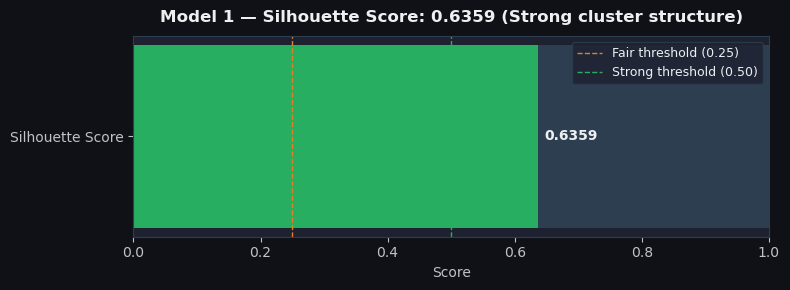

✓ Saved: figures/model1_silhouette_score.png


In [33]:
# Cell 7: Silhouette score bar chart

fig, ax = plt.subplots(figsize=(8, 3))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL_BG)

# Background bar (max possible = 1.0)
ax.barh(['Silhouette Score'], [1.0], color='#2C3E50', height=0.4)

# Actual score bar
color = '#27AE60' if sil_score > 0.5 else '#E67E22' if sil_score > 0.25 else '#C0392B'
ax.barh(['Silhouette Score'], [sil_score], color=color, height=0.4)

# Threshold lines
ax.axvline(x=0.25, color='#E67E22', linestyle='--', linewidth=1, label='Fair threshold (0.25)')
ax.axvline(x=0.5,  color='#27AE60', linestyle='--', linewidth=1, label='Strong threshold (0.50)')

ax.set_xlim(0, 1)
ax.set_xlabel('Score', color=LABEL_C)
ax.set_title(
    f'Model 1 — Silhouette Score: {sil_score:.4f} '
    f'({"Strong" if sil_score > 0.5 else "Fair" if sil_score > 0.25 else "Weak"} cluster structure)',
    color=TEXT_C, fontweight='bold', pad=10
)
ax.tick_params(colors=LABEL_C)
ax.legend(facecolor=PANEL_BG, edgecolor='#2C3E50', labelcolor=TEXT_C, fontsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor('#2C3E50')

# Annotate score on bar
ax.text(sil_score + 0.01, 0, f'{sil_score:.4f}', va='center', color=TEXT_C, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/model1_silhouette_score.png', dpi=300, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('✓ Saved: figures/model1_silhouette_score.png')

## Visualisation 2 — CGI vs IIT Rate Scatter Plot (Pearson R)

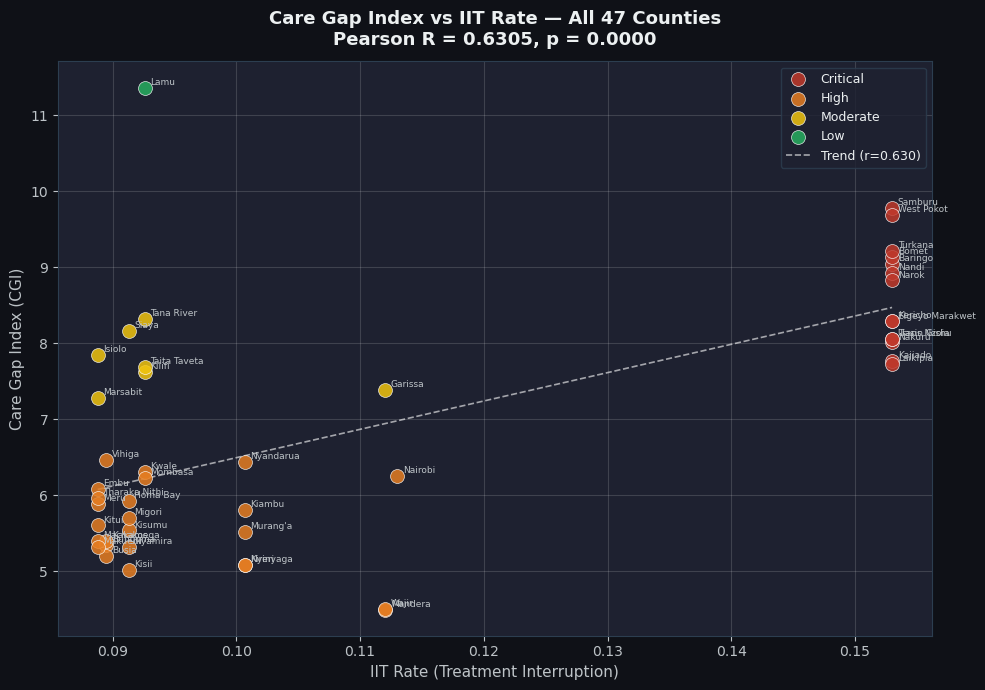

✓ Saved: figures/model1_cgi_vs_iit_scatter.png


In [36]:
# Cell 8: CGI vs IIT rate scatter plot coloured by tier
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL_BG)

for tier in TIER_LABELS:
    subset = df[df['tier'] == tier]
    color  = TIER_COLORS.get(tier, '#808080')
    ax.scatter(
        subset['iit_rate'],
        subset['care_gap_index'],
        c=color, label=tier,
        s=100, alpha=0.85, edgecolors='white', linewidths=0.5,
        zorder=3
    )
    # Annotate county names
    for _, row in subset.iterrows():
        ax.annotate(
            row['county'],
            (row['iit_rate'], row['care_gap_index']),
            fontsize=6.5, color=LABEL_C,
            xytext=(4, 2), textcoords='offset points'
        )

# Trend line
z = np.polyfit(df['iit_rate'], df['care_gap_index'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['iit_rate'].min(), df['iit_rate'].max(), 100)
ax.plot(x_line, p(x_line), color='white', linestyle='--',
        linewidth=1.2, alpha=0.6, label=f'Trend (r={r:.3f})')

ax.set_xlabel('IIT Rate (Treatment Interruption)', color=LABEL_C, fontsize=11)
ax.set_ylabel('Care Gap Index (CGI)', color=LABEL_C, fontsize=11)
ax.set_title(
    f'Care Gap Index vs IIT Rate — All 47 Counties\n'
    f'Pearson R = {r:.4f}, p = {p_value:.4f}',
    color=TEXT_C, fontsize=13, fontweight='bold', pad=12
)
ax.tick_params(colors=LABEL_C)
ax.legend(facecolor=PANEL_BG, edgecolor='#2C3E50', labelcolor=TEXT_C, fontsize=9)
ax.grid(alpha=0.15, color='white')
for sp in ax.spines.values():
    sp.set_edgecolor('#2C3E50')

plt.tight_layout()
plt.savefig('../figures/model1_cgi_vs_iit_scatter.png', dpi=300, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('✓ Saved: figures/model1_cgi_vs_iit_scatter.png')

## Visualisation 3 — Tier Distribution Bar Chart

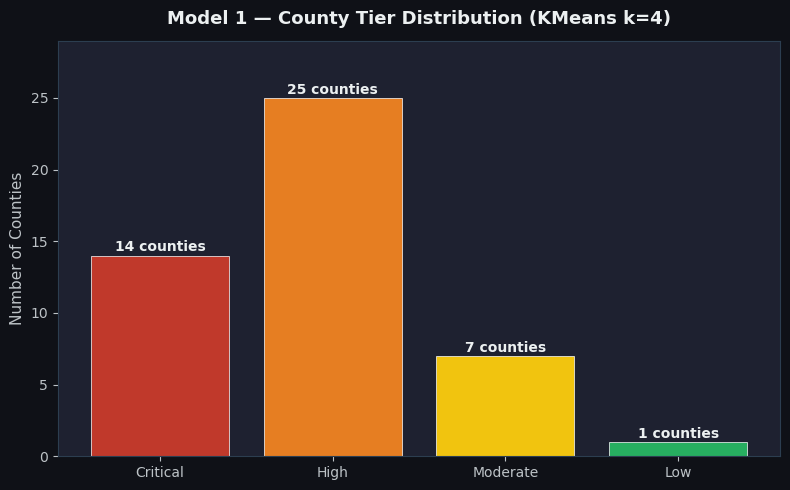

✓ Saved: figures/model1_tier_distribution.png


In [37]:
# Cell 9: Tier distribution bar chart
tier_counts = df['tier'].value_counts().reindex(TIER_LABELS)
colors_bar  = [TIER_COLORS.get(t, '#808080') for t in TIER_LABELS]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL_BG)

bars = ax.bar(TIER_LABELS, tier_counts.values, color=colors_bar,
              edgecolor='white', linewidth=0.5)

# Annotate counts on bars
for bar, count in zip(bars, tier_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{count} counties',
        ha='center', color=TEXT_C, fontsize=10, fontweight='bold'
    )

ax.set_ylabel('Number of Counties', color=LABEL_C, fontsize=11)
ax.set_title(
    'Model 1 — County Tier Distribution (KMeans k=4)',
    color=TEXT_C, fontsize=13, fontweight='bold', pad=12
)
ax.tick_params(colors=LABEL_C)
ax.set_ylim(0, max(tier_counts.values) + 4)
for sp in ax.spines.values():
    sp.set_edgecolor('#2C3E50')

plt.tight_layout()
plt.savefig('../figures/model1_tier_distribution.png', dpi=300, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('✓ Saved: figures/model1_tier_distribution.png')

## Evaluation Summary

In [39]:
# Cell 10: Final evaluation summary
print('=' * 55)
print('MODEL 1 EVALUATION SUMMARY — KMeans County Clustering')
print('=' * 55)

print(f'\n1. SILHOUETTE SCORE')
print(f'   Score          : {sil_score:.4f}')
print(f'   Interpretation : {"Strong" if sil_score > 0.5 else "Fair" if sil_score > 0.25 else "Weak"} cluster structure')
print(f'   Benchmark      : > 0.5 = strong | 0.25-0.5 = fair | < 0.25 = weak')

print(f'\n2. PEARSON R (CGI vs IIT Rate)')
print(f'   Pearson R      : {r:.4f}')
print(f'   P-value        : {p_value:.6f}')
print(f'   Significant    : {"Yes" if p_value < 0.05 else "No"}')
print(f'   Interpretation : CGI {"reliably" if r > 0.7 else "partially"} captures real programme gaps')

print(f'\n3. TIER DISTRIBUTION')
for tier in TIER_LABELS:
    n     = (df['tier'] == tier).sum()
    color = TIER_COLORS.get(tier, '')
    counties = df[df['tier'] == tier]['county'].tolist()
    print(f'   {tier:<10}: {n:>2} counties | color: {color}')
    print(f'               {counties}')

print(f'\n4. MODEL PARAMETERS')
print(f'   Algorithm      : KMeans (k={kmeans.n_clusters})')
print(f'   Features       : {features}')
print(f'   Inertia        : {kmeans.inertia_:.2f}')
print(f'   Scaler         : StandardScaler')

print(f'\n5. RECOMMENDATION')
print(f'   Model 1 is ready for MOH use.')
print(f'   Critical + High tiers ({(df["tier"].isin(["Critical","High"])).sum()} counties) ')
print(f'   are the priority targets for retention interventions.')

MODEL 1 EVALUATION SUMMARY — KMeans County Clustering

1. SILHOUETTE SCORE
   Score          : 0.6359
   Interpretation : Strong cluster structure
   Benchmark      : > 0.5 = strong | 0.25-0.5 = fair | < 0.25 = weak

2. PEARSON R (CGI vs IIT Rate)
   Pearson R      : 0.6305
   P-value        : 0.000002
   Significant    : Yes
   Interpretation : CGI partially captures real programme gaps

3. TIER DISTRIBUTION
   Critical  : 14 counties | color: #C0392B
               ['Baringo', 'Bomet', 'Elgeyo Marakwet', 'Kajiado', 'Kericho', 'Laikipia', 'Nakuru', 'Nandi', 'Narok', 'Samburu', 'Trans Nzoia', 'Turkana', 'Uasin Gishu', 'West Pokot']
   High      : 25 counties | color: #E67E22
               ['Bungoma', 'Busia', 'Embu', 'Homa Bay', 'Kakamega', 'Kiambu', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Machakos', 'Makueni', 'Mandera', 'Meru', 'Migori', 'Mombasa', "Murang'a", 'Nairobi', 'Nyamira', 'Nyandarua', 'Nyeri', 'Tharaka Nithi', 'Vihiga', 'Wajir']
   Moderate  :  7 counties | colo